**SERIES TEMPORALES**

Es una coleccion de datos indexados por un tiempo *t*, es decir ordenados cronologicament. La indexacion de una serie temporal debe ser en intervalos de una misma longitud, tales omo anual, mensual, semanal, diaria, por hora

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#abrimos el archivo
ruta = 'https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/ARCHIVOS/Ford.csv'
df = pd.read_csv (ruta, sep=',') #cuando no sale bien hay que cambiar el separador ()
df.head()

,Date,Open,High,Low,Close,Adj Close
0,2019-09-30,9.11,9.21,9.10,9.16,7.847744
1,2019-10-01,9.19,9.24,8.87,8.90,7.624991
2,2019-10-02,8.85,8.86,8.44,8.61,7.376537
3,2019-10-03,8.55,8.71,8.45,8.71,7.462211
4,2019-10-04,8.72,8.76,8.66,8.74,7.487914


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1006 non-null   object 
 1   Open       1006 non-null   float64
 2   High       1006 non-null   float64
 3   Low        1006 non-null   float64
 4   Close      1006 non-null   float64
 5   Adj Close  1006 non-null   float64
dtypes: float64(5), object(1)
memory usage: 47.3+ KB


recordar que un objeto en pandas es un texto (string)

Para convertir los objetos a datos de tiempo en este caso, usamos lo siguiente

In [ ]:
df['Date'] = pd.to_datetime(df['Date']) #convertir a serie de tiempo


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1006 entries, 0 to 1005
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1006 non-null   datetime64[ns]
 1   Open       1006 non-null   float64       
 2   High       1006 non-null   float64       
 3   Low        1006 non-null   float64       
 4   Close      1006 non-null   float64       
 5   Adj Close  1006 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 47.3 KB


In [ ]:
df = df.set_index('Date')
df.head()

,Open,High,Low,Close,Adj Close
Date,,,,,
2019-09-30,9.11,9.21,9.10,9.16,7.847744
2019-10-01,9.19,9.24,8.87,8.90,7.624991
2019-10-02,8.85,8.86,8.44,8.61,7.376537
2019-10-03,8.55,8.71,8.45,8.71,7.462211
2019-10-04,8.72,8.76,8.66,8.74,7.487914


In [ ]:
df.idxmax() #devuelve el valor de indice en el que se alcanzan los valores máximos

,0
Open,2022-01-18
High,2022-01-13
Low,2022-01-13
Close,2022-01-14
Adj Close,2022-01-14


In [ ]:
df.idxmin() #devuelve el valor de indice en el que se alcanzan los valores mínimos

,0
Open,2020-03-23
High,2020-04-03
Low,2020-03-23
Close,2020-03-23
Adj Close,2020-03-23


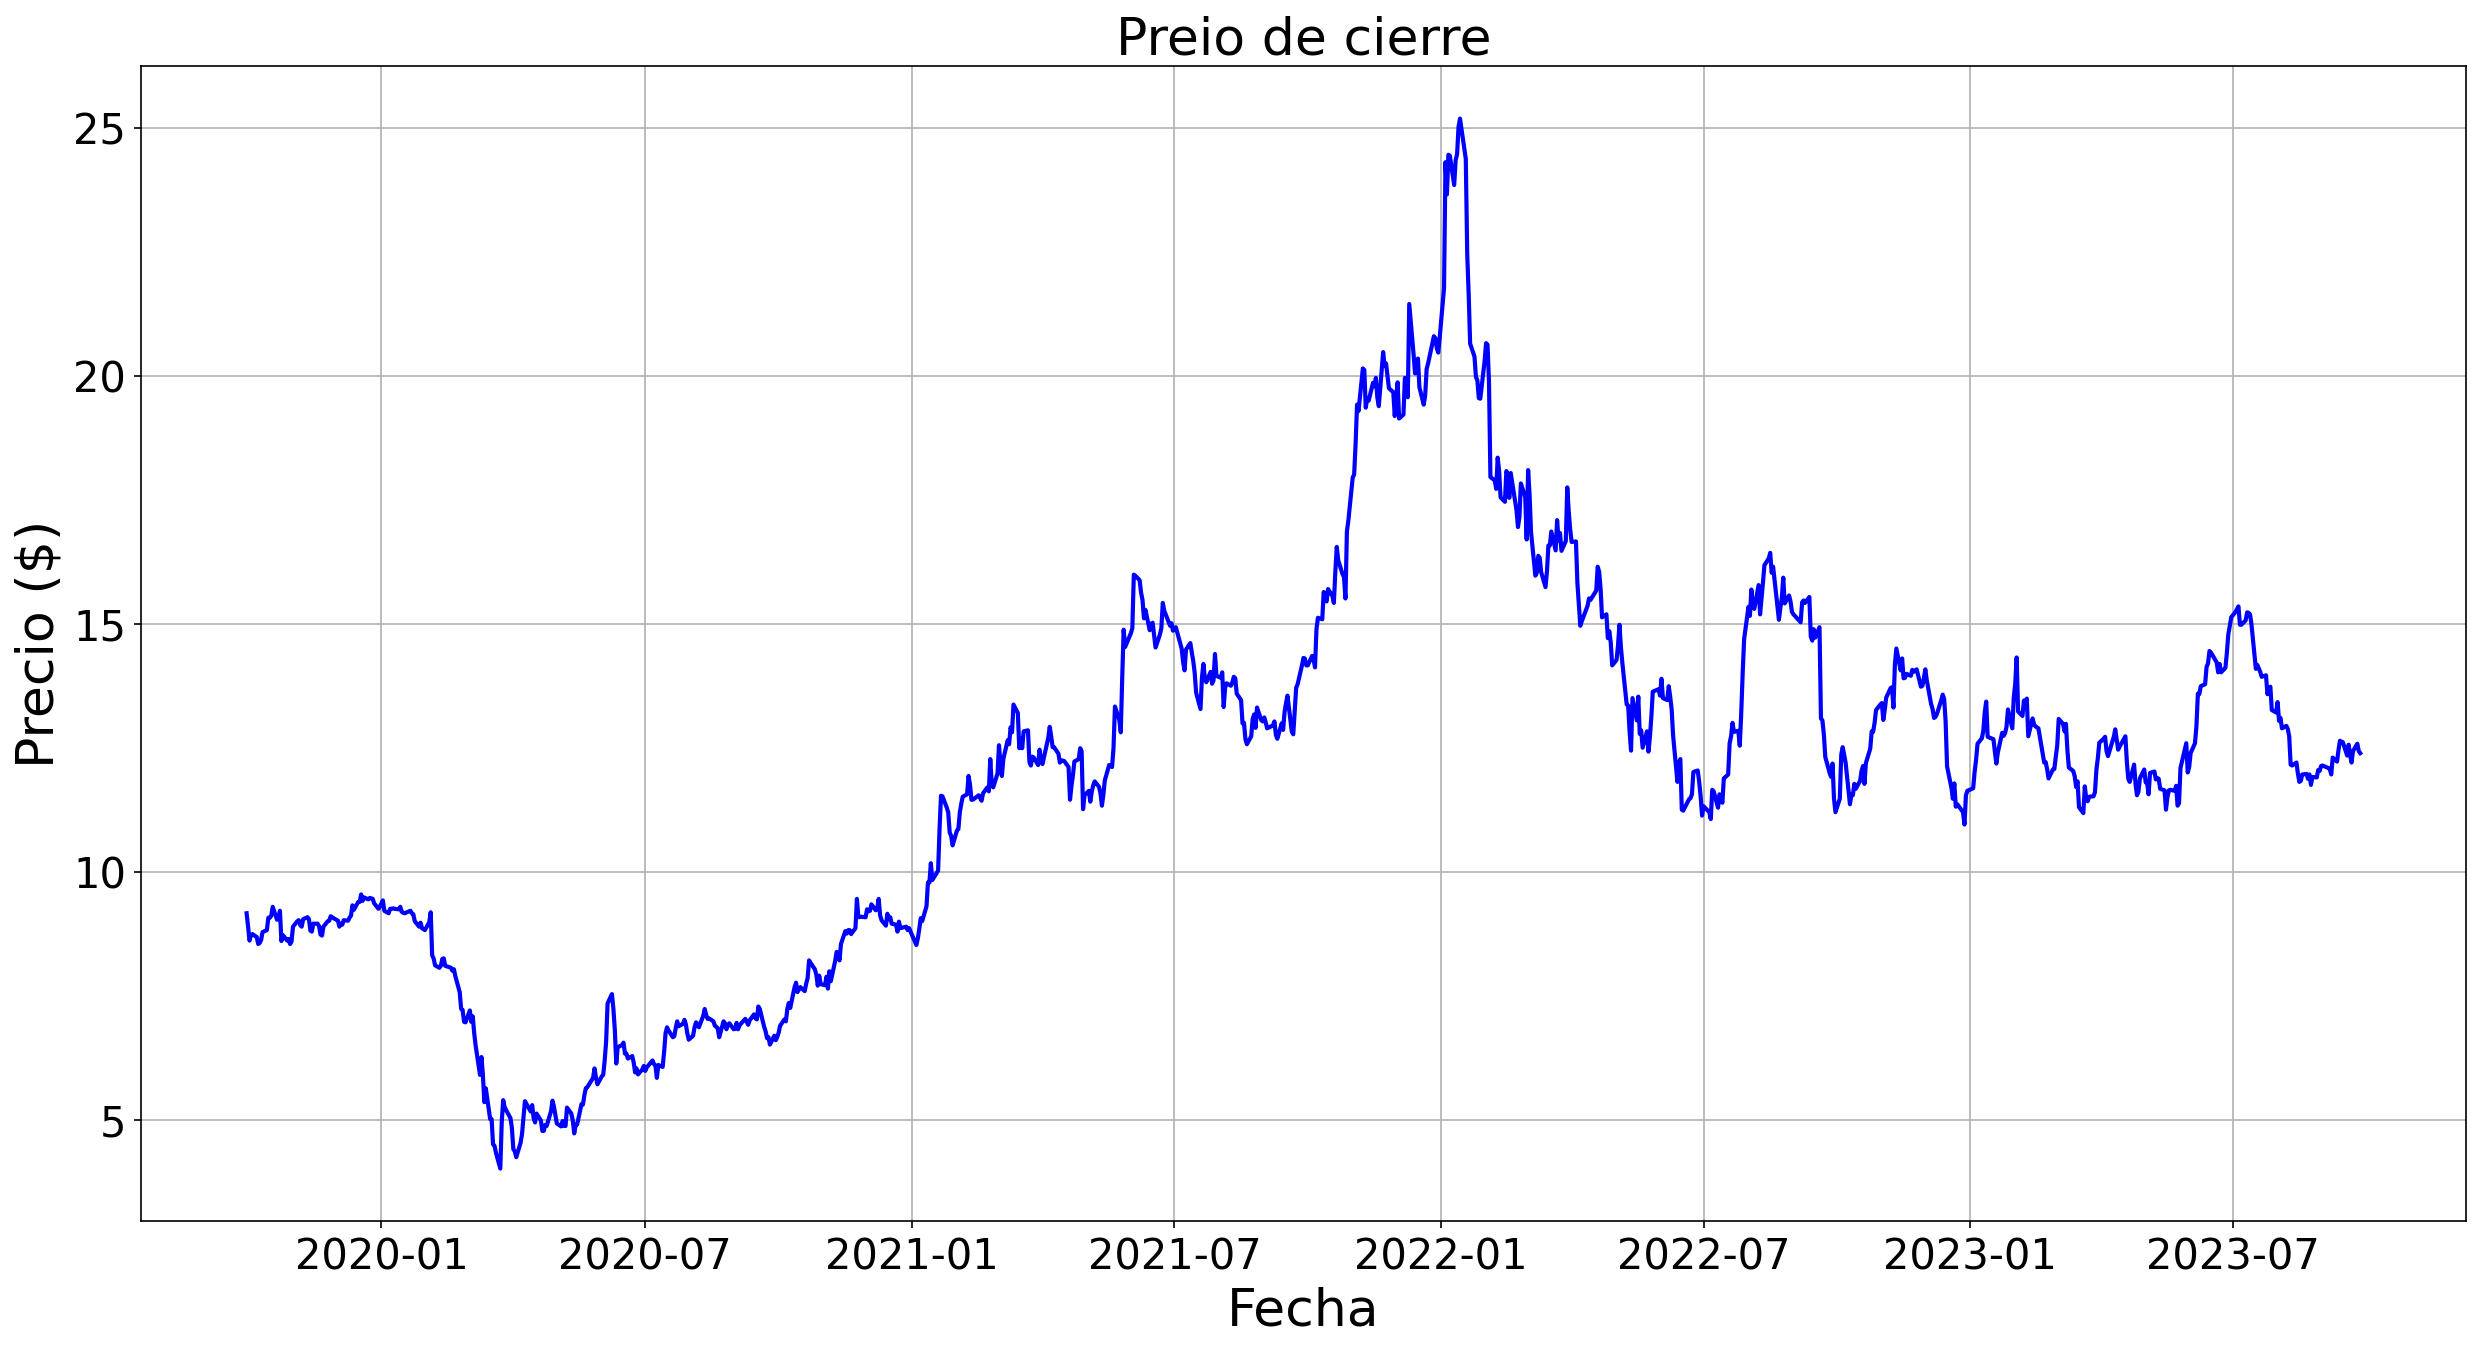

In [ ]:
plt.figure(figsize=(20,10), dpi=150)
plt.plot(df.index, df['Close'], lw=2, color='blue')
plt.xlabel('Fecha', fontdict = {'fontsize':25})
plt.ylabel('Precio ($)', fontdict = {'fontsize': 25})
plt.title('Preio de cierre', fontsize = 25)
plt.tick_params(labelsize = 20) #para el tamaño de la leyenda
plt.grid(True)
plt.show()

/tmp/ipykernel_426/567875111.py:32: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(TICKER, start=FECHA_INICIO, end=FECHA_FIN)
[*********************100%***********************]  1 of 1 completed


ValueError: 'y1' is not 1-dimensional

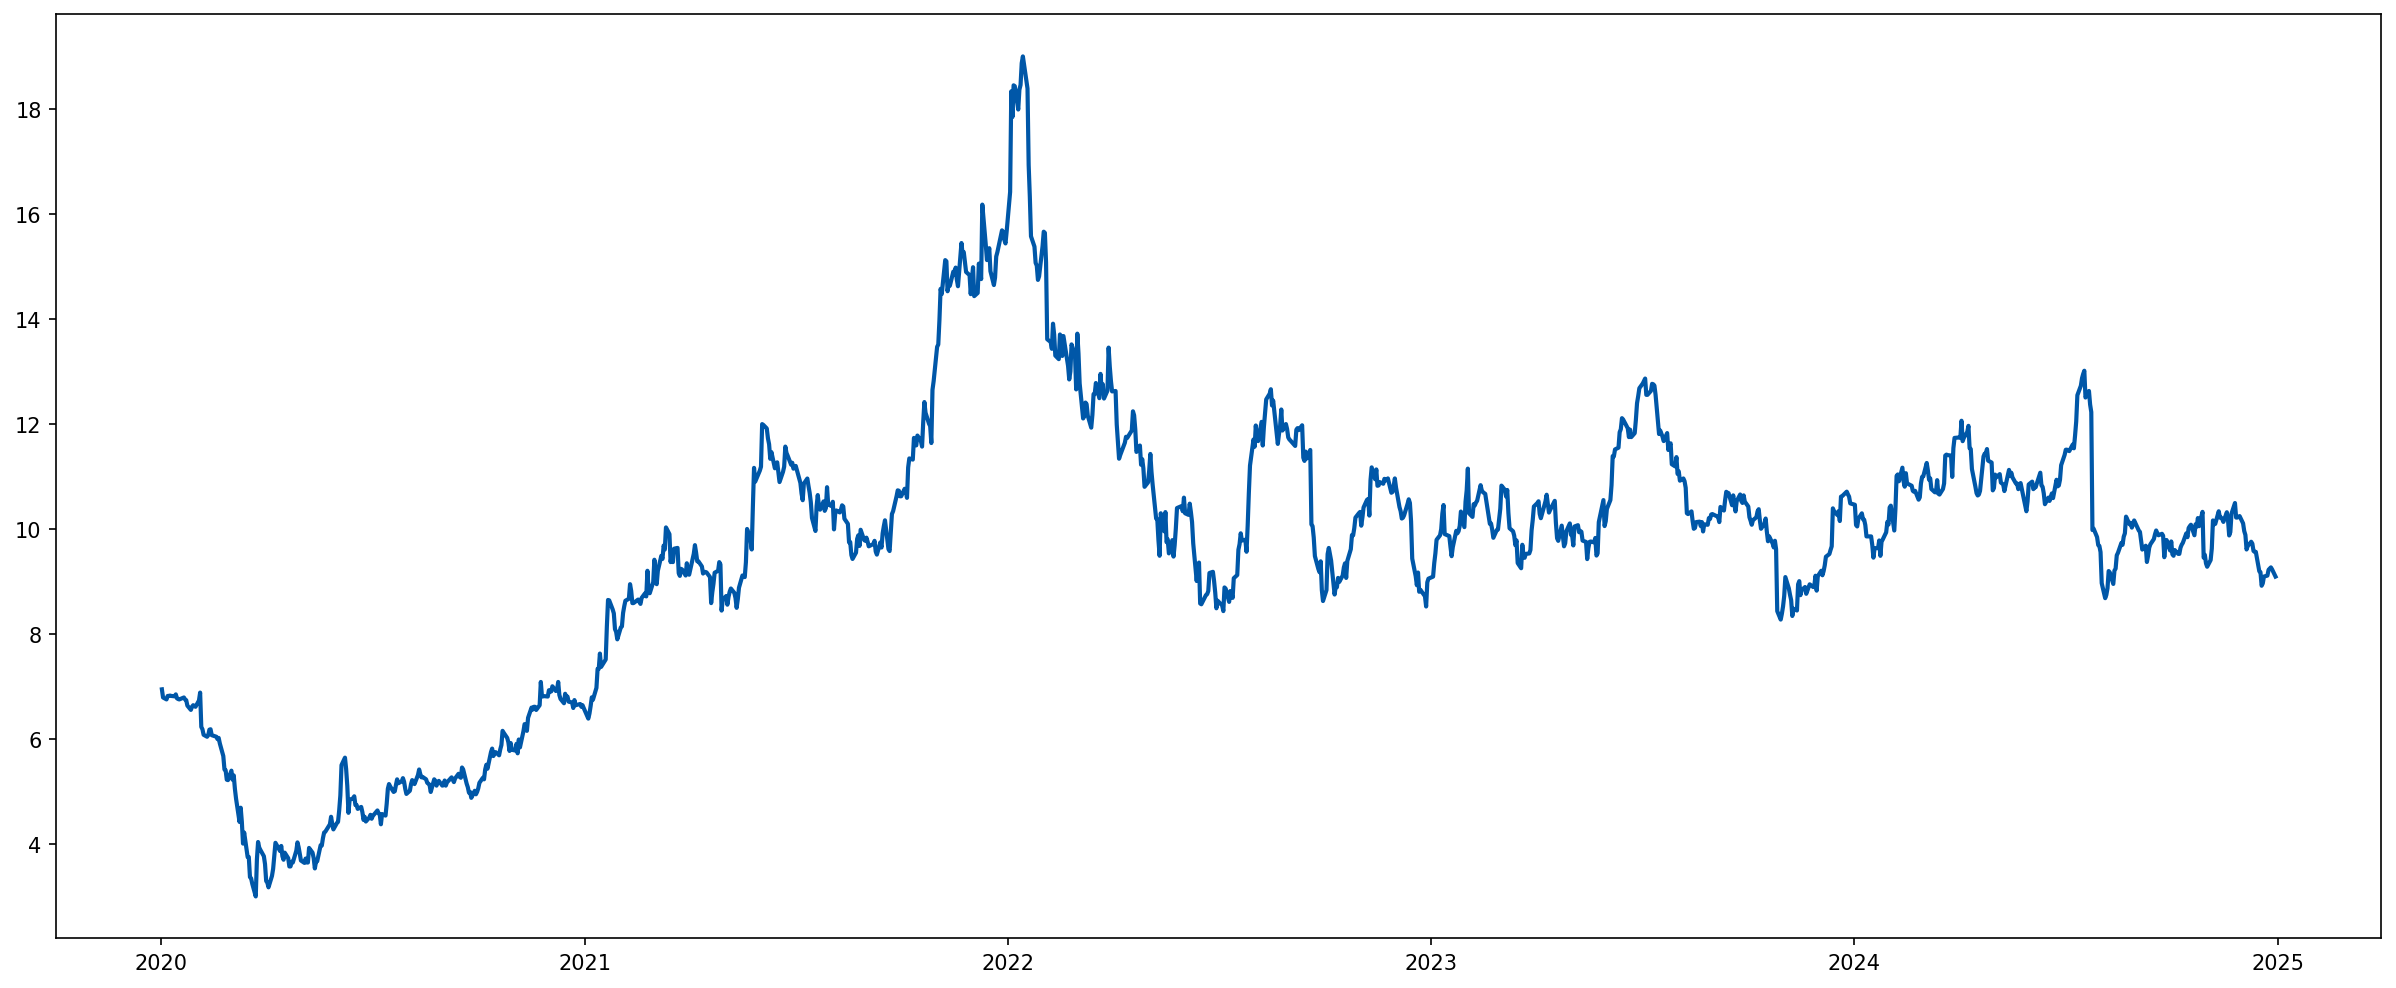

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ──────────────────────────────────────────────
# CONFIGURACIÓN — modifica estos valores fácilmente
# ──────────────────────────────────────────────
TICKER      = "F"           # Símbolo de la acción (F = Ford)
FECHA_INICIO = "2020-01-01" # Fecha de inicio del rango de datos
FECHA_FIN    = "2024-12-31" # Fecha de fin del rango de datos

# Configuración visual de la gráfica
FIGURA_ANCHO  = 20          # Ancho de la figura en pulgadas
FIGURA_ALTO   = 8           # Alto de la figura en pulgadas
FIGURA_DPI    = 150         # Resolución (puntos por pulgada)

COLOR_LINEA   = "#0057A8"   # Color de la línea (azul Ford)
GROSOR_LINEA  = 2           # Grosor de la línea
COLOR_RELLENO = "#BDD7F5"   # Color del relleno bajo la curva

TAMANIO_TITULO = 26         # Tamaño de fuente del título
TAMANIO_EJES   = 18         # Tamaño de fuente de los ejes X e Y
TAMANIO_TICKS  = 14         # Tamaño de las etiquetas de los ejes

GUARDAR_IMAGEN = False       # True para guardar la imagen, False para solo mostrarla
NOMBRE_ARCHIVO = "grafica_ford.png"  # Nombre del archivo si GUARDAR_IMAGEN = True
# ──────────────────────────────────────────────


# ── 1. DESCARGA DE DATOS ──────────────────────
# Descarga el historial de precios de la acción usando yfinance
df = yf.download(TICKER, start=FECHA_INICIO, end=FECHA_FIN)

# Verifica que se hayan descargado datos correctamente
if df.empty:
    raise ValueError(f"No se obtuvieron datos para el ticker '{TICKER}'. Verifica el símbolo y las fechas.")


# ── 2. PREPARACIÓN DE DATOS ───────────────────
# Se trabaja solo con la columna 'Close' (precio de cierre)
# El índice del DataFrame ya contiene las fechas
precio_cierre = df["Close"]


# ── 3. CREACIÓN DE LA FIGURA ──────────────────
fig, ax = plt.subplots(figsize=(FIGURA_ANCHO, FIGURA_ALTO), dpi=FIGURA_DPI)
# fig: objeto figura (contenedor general)
# ax:  objeto ejes (donde se dibuja la gráfica)


# ── 4. TRAZADO DE LA LÍNEA ────────────────────
ax.plot(
    precio_cierre.index,   # Eje X: fechas
    precio_cierre,         # Eje Y: precios de cierre
    lw=GROSOR_LINEA,       # Grosor de la línea
    color=COLOR_LINEA,     # Color de la línea
    zorder=3               # Prioridad de capas (3 = encima del relleno y la cuadrícula)
)

# Relleno de color debajo de la línea para mejor legibilidad visual
ax.fill_between(
    precio_cierre.index,   # Eje X: fechas
    precio_cierre,         # Valor superior del relleno
    alpha=0.25,            # Transparencia del relleno (0=transparente, 1=sólido)
    color=COLOR_RELLENO    # Color del relleno
)


# ── 5. FORMATO DEL EJE X (fechas) ────────────
# Muestra una marca (tick) por año
ax.xaxis.set_major_locator(mdates.YearLocator())
# Formatea las etiquetas como "Ene 2020", "Ene 2021", etc.
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
# Rota las etiquetas para evitar solapamiento
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")


# ── 6. ETIQUETAS Y TÍTULO ─────────────────────
ax.set_xlabel("Fecha",            fontsize=TAMANIO_EJES, labelpad=10) # Etiqueta del eje X
ax.set_ylabel("Precio de Cierre ($)", fontsize=TAMANIO_EJES, labelpad=10) # Etiqueta del eje Y
ax.set_title(
    f"Precio de Cierre — Ford Motor Co. ({TICKER})\n{FECHA_INICIO}  a  {FECHA_FIN}",
    fontsize=TAMANIO_TITULO,
    fontweight="bold",
    pad=15  # Separación entre el título y la gráfica
)


# ── 7. CUADRÍCULA Y ESTILO ────────────────────
ax.grid(True, linestyle="--", alpha=0.5, zorder=0) # Cuadrícula punteada semitransparente
ax.tick_params(labelsize=TAMANIO_TICKS)             # Tamaño de las etiquetas de los ejes
ax.spines[["top", "right"]].set_visible(False)      # Oculta los bordes superior y derecho


# ── 8. ESTADÍSTICAS EN LA GRÁFICA (opcional) ──
precio_min = precio_cierre.min()   # Precio mínimo del periodo
precio_max = precio_cierre.max()   # Precio máximo del periodo
precio_ult = precio_cierre.iloc[-1] # Último precio de cierre registrado

# Muestra un cuadro de texto con estadísticas clave
texto_stats = (
    f"Mín:  ${precio_min:.2f}\n"
    f"Máx: ${precio_max:.2f}\n"
    f"Último: ${precio_ult:.2f}"
)
ax.text(
    0.01, 0.97,              # Posición (en coordenadas relativas: 0=izquierda/abajo, 1=derecha/arriba)
    texto_stats,
    transform=ax.transAxes,  # Coordenadas relativas a los ejes
    fontsize=13,
    verticalalignment="top",
    bbox=dict(               # Cuadro de fondo del texto
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="#CCCCCC",
        alpha=0.85
    )
)


# ── 9. AJUSTE Y EXPORTACIÓN ───────────────────
plt.tight_layout()  # Ajusta automáticamente los márgenes para evitar recortes

if GUARDAR_IMAGEN:
    # Guarda la figura como imagen PNG en disco
    plt.savefig(NOMBRE_ARCHIVO, bbox_inches="tight")
    print(f"Gráfica guardada como '{NOMBRE_ARCHIVO}'")

plt.show()  # Muestra la gráfica en pantalla

Tengo un DataFrame de pandas llamado df con datos históricos de la acción de Ford (ticker: F), donde el índice son fechas (DatetimeIndex) y existe una columna llamada Close con los precios de cierre diarios.
Escribe un script de Python completo y listo para ejecutar que genere una gráfica de nivel universitario/profesional del precio de cierre vs. fecha. El código debe cumplir con lo siguiente:
1. Sección de configuración centralizada al inicio Todas las variables modificables deben estar agrupadas al inicio del script con nombres en mayúsculas (TICKER, FECHA_INICIO, FECHA_FIN, COLOR_LINEA, FORMATO_FECHA, INTERVALO_MESES, etc.) para que cualquier ajuste se haga en un solo lugar sin tocar el resto del código.
2. Descarga de datos robusta Usar yfinance para descargar los datos. Manejar el caso en que yfinance retorne columnas con MultiIndex (usando .squeeze() y .astype(float)). Convertir el índice a datetime64[ns] para compatibilidad con matplotlib. Validar que el DataFrame no esté vacío y lanzar un error descriptivo si lo está.
3. Gráfica de calidad profesional con matplotlib
* Línea de precio con relleno semitransparente debajo
* Eje X con fechas completas en formato DD/MM/YYYY, rotadas 45°, con intervalo de meses configurable (MonthLocator)
* Anotación del precio máximo y mínimo directamente sobre la gráfica con flechas (ax.annotate)
* Cuadro de estadísticas (mín, máx, último precio, variación %) en esquina superior izquierda
* Línea horizontal punteada en el precio promedio del periodo
* Cuadrícula sutil, sin bordes superior ni derecho (spines)
* Título con nombre completo de la empresa, ticker y rango de fechas
* tight_layout() para evitar recortes
4. Opción de exportar la imagen Variable booleana GUARDAR_IMAGEN que, si es True, guarda el archivo como PNG con bbox_inches='tight'.
5. Comentarios en cada línea o bloque Cada línea o bloque debe tener un comentario en español que explique:
* Qué hace esa instrucción
* Por qué es necesaria o qué problema resuelve
Usa secciones separadas con comentarios tipo # ── N. NOMBRE DE SECCIÓN ─── para que el código sea fácil de navegar.

Código:
plt.figure(figsize=(20,10), dpi=150) plt.plot(df.index, df['Close'], lw=2, color='blue') plt.xlabel('Fecha', fontdict = {'fontsize':25}) plt.ylabel('Precio ($)', fontdict = {'fontsize': 25})   plt.title('Preio de cierre', fontsize = 25) plt.tick_params(labelsize = 20) #para el tamaño de la leyenda plt.grid(True) plt.show()

[*********************100%***********************]  1 of 1 completed


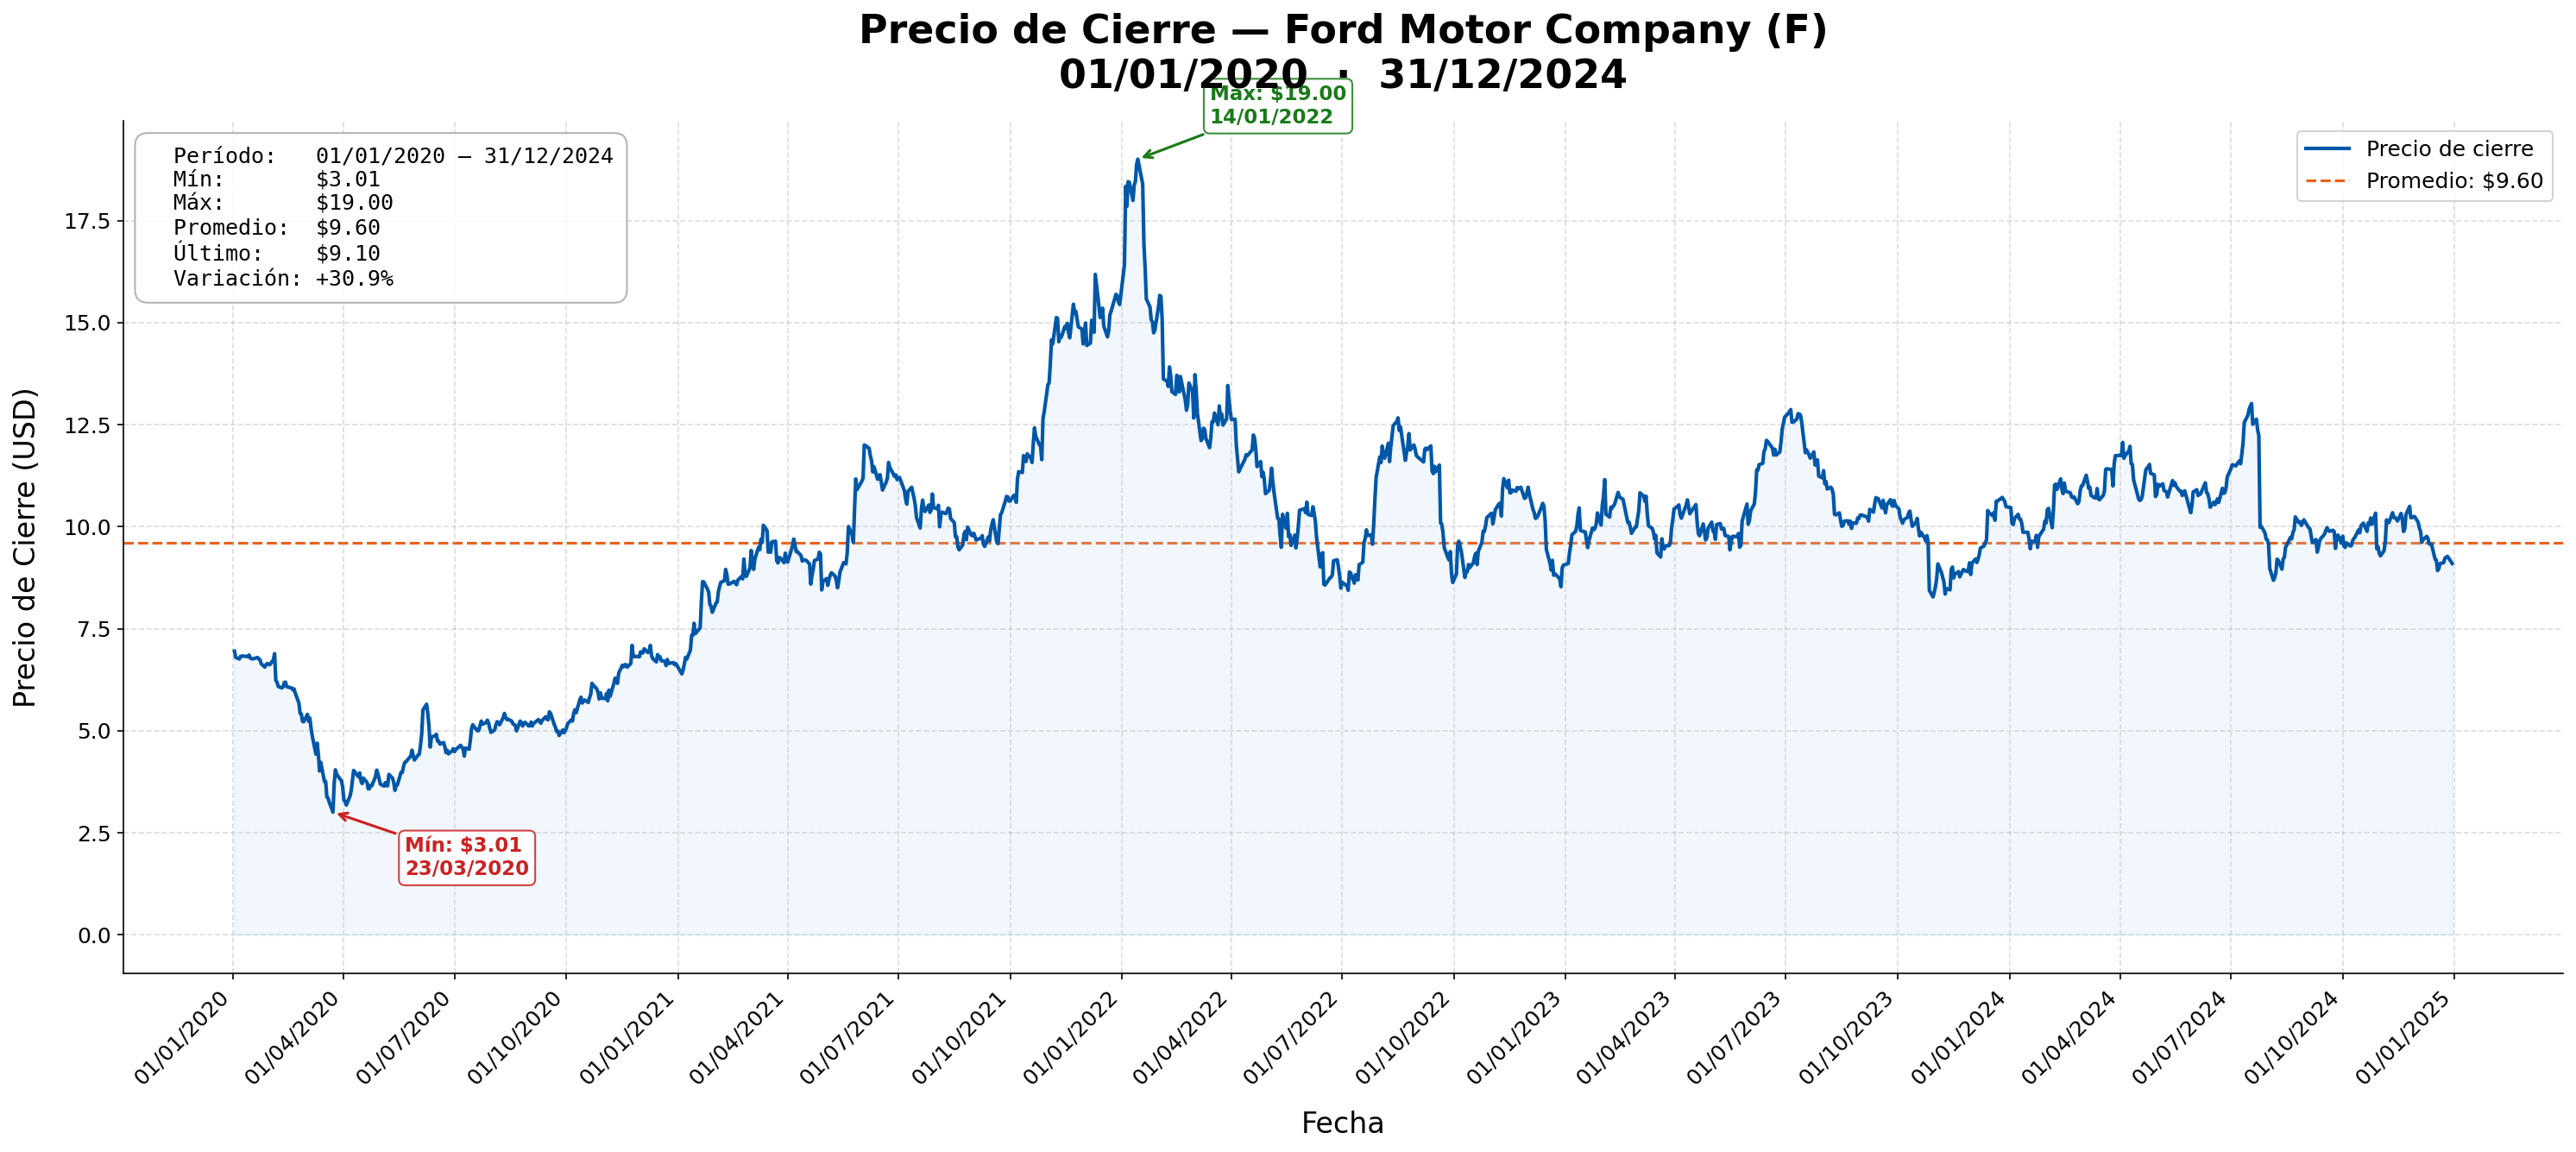

In [ ]:
import yfinance as yf                  # Librería para descargar datos históricos de acciones desde Yahoo Finance
import matplotlib.pyplot as plt        # Librería principal para crear gráficas en Python
import matplotlib.dates as mdates      # Módulo de matplotlib para formatear fechas en los ejes
from datetime import datetime          # Para convertir cadenas de texto a objetos de fecha


# ══════════════════════════════════════════════════════════════════════
# ── 1. CONFIGURACIÓN CENTRALIZADA ────────────────────────────────────
#    Todas las variables modificables están aquí. No toques el resto
#    del código; solo ajusta estos valores según lo que necesites.
# ══════════════════════════════════════════════════════════════════════

# — Datos —
TICKER         = "F"                   # Símbolo bursátil de la acción (F = Ford Motor Company)
NOMBRE_EMPRESA = "Ford Motor Company"  # Nombre completo para el título de la gráfica
FECHA_INICIO   = "2020-01-01"          # Fecha de inicio del periodo (formato YYYY-MM-DD)
FECHA_FIN      = "2024-12-31"          # Fecha de fin del periodo    (formato YYYY-MM-DD)

# — Tamaño y resolución —
FIGURA_ANCHO = 20                      # Ancho de la figura en pulgadas
FIGURA_ALTO  = 9                       # Alto de la figura en pulgadas
FIGURA_DPI   = 150                     # Resolución en puntos por pulgada (mayor = más nítida)

# — Colores —
COLOR_LINEA    = "#0057A8"             # Color principal de la línea  (azul corporativo Ford)
COLOR_RELLENO  = "#BDD7F5"             # Color del área rellena bajo la curva
COLOR_PROMEDIO = "#E8621A"             # Color de la línea de precio promedio
COLOR_MAXIMO   = "#1A7A1A"             # Color de la anotación del precio máximo
COLOR_MINIMO   = "#CC2222"             # Color de la anotación del precio mínimo

# — Grosor de líneas —
GROSOR_LINEA    = 2.0                  # Grosor de la línea de precio en puntos
GROSOR_PROMEDIO = 1.5                  # Grosor de la línea de precio promedio

# — Tamaños de fuente —
TAMANIO_TITULO = 22                    # Tamaño de fuente del título principal
TAMANIO_EJES   = 16                    # Tamaño de fuente de las etiquetas de los ejes
TAMANIO_TICKS  = 12                    # Tamaño de las etiquetas numéricas sobre los ejes
TAMANIO_STATS  = 12                    # Tamaño del texto dentro del cuadro de estadísticas
TAMANIO_ANNOT  = 11                    # Tamaño del texto de las anotaciones de máx/mín

# — Eje X (fechas) —
FORMATO_FECHA   = "%d/%m/%Y"           # Formato de fecha: DD/MM/YYYY  (ej: 15/03/2021)
INTERVALO_MESES = 3                    # Intervalo entre etiquetas: 3=trimestral, 6=semestral, 12=anual

# — Exportación —
GUARDAR_IMAGEN = False                 # True = guarda la imagen en disco | False = solo la muestra
NOMBRE_ARCHIVO = "grafica_ford.png"   # Nombre del archivo PNG de salida


# ══════════════════════════════════════════════════════════════════════
# ── 2. DESCARGA Y VALIDACIÓN DE DATOS ────────────────────────────────
#    Se obtienen los datos desde Yahoo Finance y se verifica que sean
#    válidos antes de intentar graficar.
# ══════════════════════════════════════════════════════════════════════

# Descarga el historial de precios OHLCV (Open, High, Low, Close, Volume)
# auto_adjust=True ajusta automáticamente por dividendos y splits (más preciso)
df = yf.download(TICKER, start=FECHA_INICIO, end=FECHA_FIN, auto_adjust=True)

# Si el DataFrame viene vacío significa que el ticker o las fechas son inválidos
if df.empty:
    raise ValueError(
        f"No se descargaron datos para '{TICKER}' entre {FECHA_INICIO} y {FECHA_FIN}.\n"
        "Verifica el símbolo del ticker y que el rango de fechas sea válido."
    )

# ── 2a. Limpieza del MultiIndex ───────────────────────────────────────
# Las versiones recientes de yfinance devuelven columnas con dos niveles:
#   nivel 0 → métrica ("Close", "Open"…)   nivel 1 → ticker ("F")
# .squeeze() colapsa el nivel del ticker dejando una Serie 1D simple.
# .astype(float) garantiza tipo numérico puro; evita errores en fill_between.
precio_cierre = df["Close"].squeeze().astype(float)

# ── 2b. Normalización del índice de fechas ────────────────────────────
# Convierte el índice a datetime64[ns] sin zona horaria.
# matplotlib necesita este formato exacto para aplicar mdates correctamente.
precio_cierre.index = precio_cierre.index.astype("datetime64[ns]")


# ══════════════════════════════════════════════════════════════════════
# ── 3. CÁLCULO DE ESTADÍSTICAS ───────────────────────────────────────
#    Se calculan antes de graficar para usarlas en anotaciones y cuadro.
# ══════════════════════════════════════════════════════════════════════

precio_min    = precio_cierre.min()                              # Precio mínimo del periodo
precio_max    = precio_cierre.max()                              # Precio máximo del periodo
precio_prom   = precio_cierre.mean()                             # Precio promedio del periodo
precio_ini    = precio_cierre.iloc[0]                            # Primer precio de cierre registrado
precio_ult    = precio_cierre.iloc[-1]                           # Último precio de cierre registrado
variacion_pct = (precio_ult - precio_ini) / precio_ini * 100    # Variación % total del periodo

fecha_max = precio_cierre.idxmax()   # Fecha exacta en que ocurrió el precio máximo
fecha_min = precio_cierre.idxmin()   # Fecha exacta en que ocurrió el precio mínimo


# ══════════════════════════════════════════════════════════════════════
# ── 4. CREACIÓN DE LA FIGURA Y EJES ──────────────────────────────────
#    Se usa la interfaz orientada a objetos (fig, ax) en lugar de plt.*
#    porque da control total sobre cada elemento de la gráfica.
# ══════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(FIGURA_ANCHO, FIGURA_ALTO), dpi=FIGURA_DPI)
# fig → objeto contenedor de toda la figura (fondo, tamaño, resolución)
# ax  → área de dibujo donde se trazan datos, ejes, etiquetas y anotaciones


# ══════════════════════════════════════════════════════════════════════
# ── 5. TRAZADO DE DATOS ──────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════

# — 5a. Línea de precio de cierre —
ax.plot(
    precio_cierre.index,            # Eje X: fechas en formato datetime64
    precio_cierre.values,           # Eje Y: array NumPy 1D (.values evita el error del MultiIndex)
    lw=GROSOR_LINEA,                # Grosor de la línea
    color=COLOR_LINEA,              # Color configurado en la sección 1
    zorder=3,                       # Capa 3 = encima del relleno (2) y la cuadrícula (0)
    label="Precio de cierre"        # Etiqueta para la leyenda
)

# — 5b. Relleno bajo la curva —
# fill_between dibuja un área coloreada entre la curva y el eje Y=0.
# Facilita ver visualmente la tendencia y los cambios de nivel.
ax.fill_between(
    precio_cierre.index,            # Eje X: mismo índice de fechas
    precio_cierre.values,           # Límite superior del relleno (la curva misma)
    alpha=0.20,                     # Transparencia: 0=invisible, 1=sólido
    color=COLOR_RELLENO,            # Color del área
    zorder=2                        # Capa 2: debajo de la línea pero encima de la cuadrícula
)

# — 5c. Línea horizontal del precio promedio —
# axhline traza una línea horizontal que cruza toda la gráfica en y=precio_prom.
# Sirve de referencia para identificar periodos por encima/debajo del promedio.
ax.axhline(
    y=precio_prom,                  # Posición vertical: el precio promedio calculado
    color=COLOR_PROMEDIO,           # Color diferenciado para destacarla
    linestyle="--",                 # Línea punteada para distinguirla de la curva principal
    lw=GROSOR_PROMEDIO,             # Grosor configurable
    zorder=1,                       # Debajo de la curva principal
    label=f"Promedio: ${precio_prom:.2f}"   # Etiqueta para la leyenda
)


# ══════════════════════════════════════════════════════════════════════
# ── 6. ANOTACIONES DE MÁXIMO Y MÍNIMO ────────────────────────────────
#    ax.annotate dibuja texto + flecha apuntando a un punto de datos.
#    xytext define el desplazamiento del texto en píxeles (offset points).
# ══════════════════════════════════════════════════════════════════════

# — 6a. Anotación del precio máximo —
ax.annotate(
    f"Máx: ${precio_max:.2f}\n{fecha_max.strftime('%d/%m/%Y')}",  # Texto con precio y fecha
    xy=(fecha_max, precio_max),          # Punta de la flecha: punto exacto del máximo
    xytext=(40, 20),                     # Texto desplazado 40px a la derecha y 20px arriba
    textcoords="offset points",          # Indica que xytext son píxeles, no coordenadas de datos
    fontsize=TAMANIO_ANNOT,
    color=COLOR_MAXIMO,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",                 # Flecha con punta simple
        color=COLOR_MAXIMO,
        lw=1.5
    ),
    bbox=dict(
        boxstyle="round,pad=0.3",        # Cuadro con bordes redondeados
        facecolor="white",
        edgecolor=COLOR_MAXIMO,
        alpha=0.85
    )
)

# — 6b. Anotación del precio mínimo —
ax.annotate(
    f"Mín: ${precio_min:.2f}\n{fecha_min.strftime('%d/%m/%Y')}",
    xy=(fecha_min, precio_min),          # Punta de la flecha: punto exacto del mínimo
    xytext=(40, -35),                    # Texto desplazado hacia abajo para no tapar la curva
    textcoords="offset points",
    fontsize=TAMANIO_ANNOT,
    color=COLOR_MINIMO,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        color=COLOR_MINIMO,
        lw=1.5
    ),
    bbox=dict(
        boxstyle="round,pad=0.3",
        facecolor="white",
        edgecolor=COLOR_MINIMO,
        alpha=0.85
    )
)


# ══════════════════════════════════════════════════════════════════════
# ── 7. FORMATO DEL EJE X (fechas) ────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════

# Coloca una marca (tick) cada INTERVALO_MESES meses en el eje X
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=INTERVALO_MESES))

# Formatea cada etiqueta del eje X con el patrón definido en FORMATO_FECHA
ax.xaxis.set_major_formatter(mdates.DateFormatter(FORMATO_FECHA))

# Rota las etiquetas 45° y las alinea a la derecha para evitar solapamientos
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=TAMANIO_TICKS)

# Aplica el mismo tamaño de fuente al eje Y
ax.tick_params(axis="y", labelsize=TAMANIO_TICKS)


# ══════════════════════════════════════════════════════════════════════
# ── 8. ETIQUETAS, TÍTULO Y LEYENDA ───────────────────────────────────
# ══════════════════════════════════════════════════════════════════════

ax.set_xlabel("Fecha", fontsize=TAMANIO_EJES, labelpad=12)                   # Etiqueta eje X
ax.set_ylabel("Precio de Cierre (USD)", fontsize=TAMANIO_EJES, labelpad=12)  # Etiqueta eje Y

# Convierte las fechas de configuración (YYYY-MM-DD) a DD/MM/YYYY para el título
titulo_inicio = datetime.strptime(FECHA_INICIO, "%Y-%m-%d").strftime("%d/%m/%Y")
titulo_fin    = datetime.strptime(FECHA_FIN,    "%Y-%m-%d").strftime("%d/%m/%Y")

ax.set_title(
    f"Precio de Cierre — {NOMBRE_EMPRESA} ({TICKER})\n"
    f"{titulo_inicio}  ·  {titulo_fin}",
    fontsize=TAMANIO_TITULO,
    fontweight="bold",
    pad=18   # Espacio entre el título y el borde superior de la gráfica
)

# Leyenda en la esquina superior derecha, con fondo ligeramente transparente
ax.legend(fontsize=12, loc="upper right", framealpha=0.85)


# ══════════════════════════════════════════════════════════════════════
# ── 9. CUADRÍCULA Y ESTILO VISUAL ────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════

ax.grid(True, linestyle="--", alpha=0.45, zorder=0)       # Cuadrícula punteada detrás de todo
ax.spines[["top", "right"]].set_visible(False)             # Oculta bordes superior y derecho (convención académica)
ax.spines[["left", "bottom"]].set_linewidth(0.8)           # Suaviza los bordes visibles


# ══════════════════════════════════════════════════════════════════════
# ── 10. CUADRO DE ESTADÍSTICAS ───────────────────────────────────────
#     transform=ax.transAxes usa coordenadas relativas (0–1) fijas
#     en la esquina, independientes de la escala de los datos.
# ══════════════════════════════════════════════════════════════════════

signo = "+" if variacion_pct >= 0 else ""   # Agrega "+" si la variación es positiva

texto_stats = (
    f"  Período:   {titulo_inicio} – {titulo_fin}\n"
    f"  Mín:       ${precio_min:.2f}\n"
    f"  Máx:       ${precio_max:.2f}\n"
    f"  Promedio:  ${precio_prom:.2f}\n"
    f"  Último:    ${precio_ult:.2f}\n"
    f"  Variación: {signo}{variacion_pct:.1f}%"
)

ax.text(
    0.01, 0.97,              # x=1% desde la izquierda, y=97% desde abajo (esquina superior izq.)
    texto_stats,
    transform=ax.transAxes,  # Coordenadas relativas al área de la gráfica, no a los datos
    fontsize=TAMANIO_STATS,
    verticalalignment="top", # El texto crece hacia abajo desde la coordenada y
    fontfamily="monospace",  # Fuente monoespaciada para alinear columnas de números
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="white",
        edgecolor="#AAAAAA",
        alpha=0.88
    )
)


# ══════════════════════════════════════════════════════════════════════
# ── 11. AJUSTE FINAL Y SALIDA ─────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════

# tight_layout ajusta márgenes para que etiquetas rotadas y el título
# no queden recortados al renderizar o exportar la imagen
plt.tight_layout()

if GUARDAR_IMAGEN:
    plt.savefig(
        NOMBRE_ARCHIVO,
        bbox_inches="tight",   # Incluye todo el contenido sin recortar bordes
        dpi=FIGURA_DPI         # Mantiene la resolución definida en la configuración
    )
    print(f"Gráfica guardada como '{NOMBRE_ARCHIVO}'")

plt.show()   # Muestra la gráfica en pantalla (o en el notebook si usas Jupyter)

Ejercicio: Caso Walmart de México

Obtener el gráfico del precio de cierre

In [ ]:
#abrimos el archivo
ruta = 'https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/WALMEX.csv'
df = pd.read_csv (ruta, sep=',') #cuando no sale bien hay que cambiar el separador ()
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2022-07-01,69.68,70.83,68.66,70.23,68.81,7838854.0
1,2022-07-04,70.19,71.51,69.48,69.79,68.38,2529165.0
2,2022-07-05,69.51,70.00,67.93,69.66,68.25,11473504.0
3,2022-07-06,69.27,70.87,68.61,68.83,67.45,7774514.0
4,2022-07-07,68.84,69.73,68.66,68.90,67.51,8896357.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       252 non-null    object 
 1   Open       252 non-null    float64
 2   High       252 non-null    float64
 3   Low        252 non-null    float64
 4   Close      252 non-null    float64
 5   Adj Close  252 non-null    float64
 6   Volume     252 non-null    float64
dtypes: float64(6), object(1)
memory usage: 13.9+ KB


In [ ]:
df['Date'] = pd.to_datetime(df['Date']) #convertir a serie de tiempo

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       252 non-null    datetime64[ns]
 1   Open       252 non-null    float64       
 2   High       252 non-null    float64       
 3   Low        252 non-null    float64       
 4   Close      252 non-null    float64       
 5   Adj Close  252 non-null    float64       
 6   Volume     252 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 13.9 KB


In [ ]:
df = df.set_index('Date')

In [ ]:
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2022-07-01,69.68,70.83,68.66,70.23,68.81,7838854.0
2022-07-04,70.19,71.51,69.48,69.79,68.38,2529165.0
2022-07-05,69.51,70.00,67.93,69.66,68.25,11473504.0
2022-07-06,69.27,70.87,68.61,68.83,67.45,7774514.0
2022-07-07,68.84,69.73,68.66,68.90,67.51,8896357.0


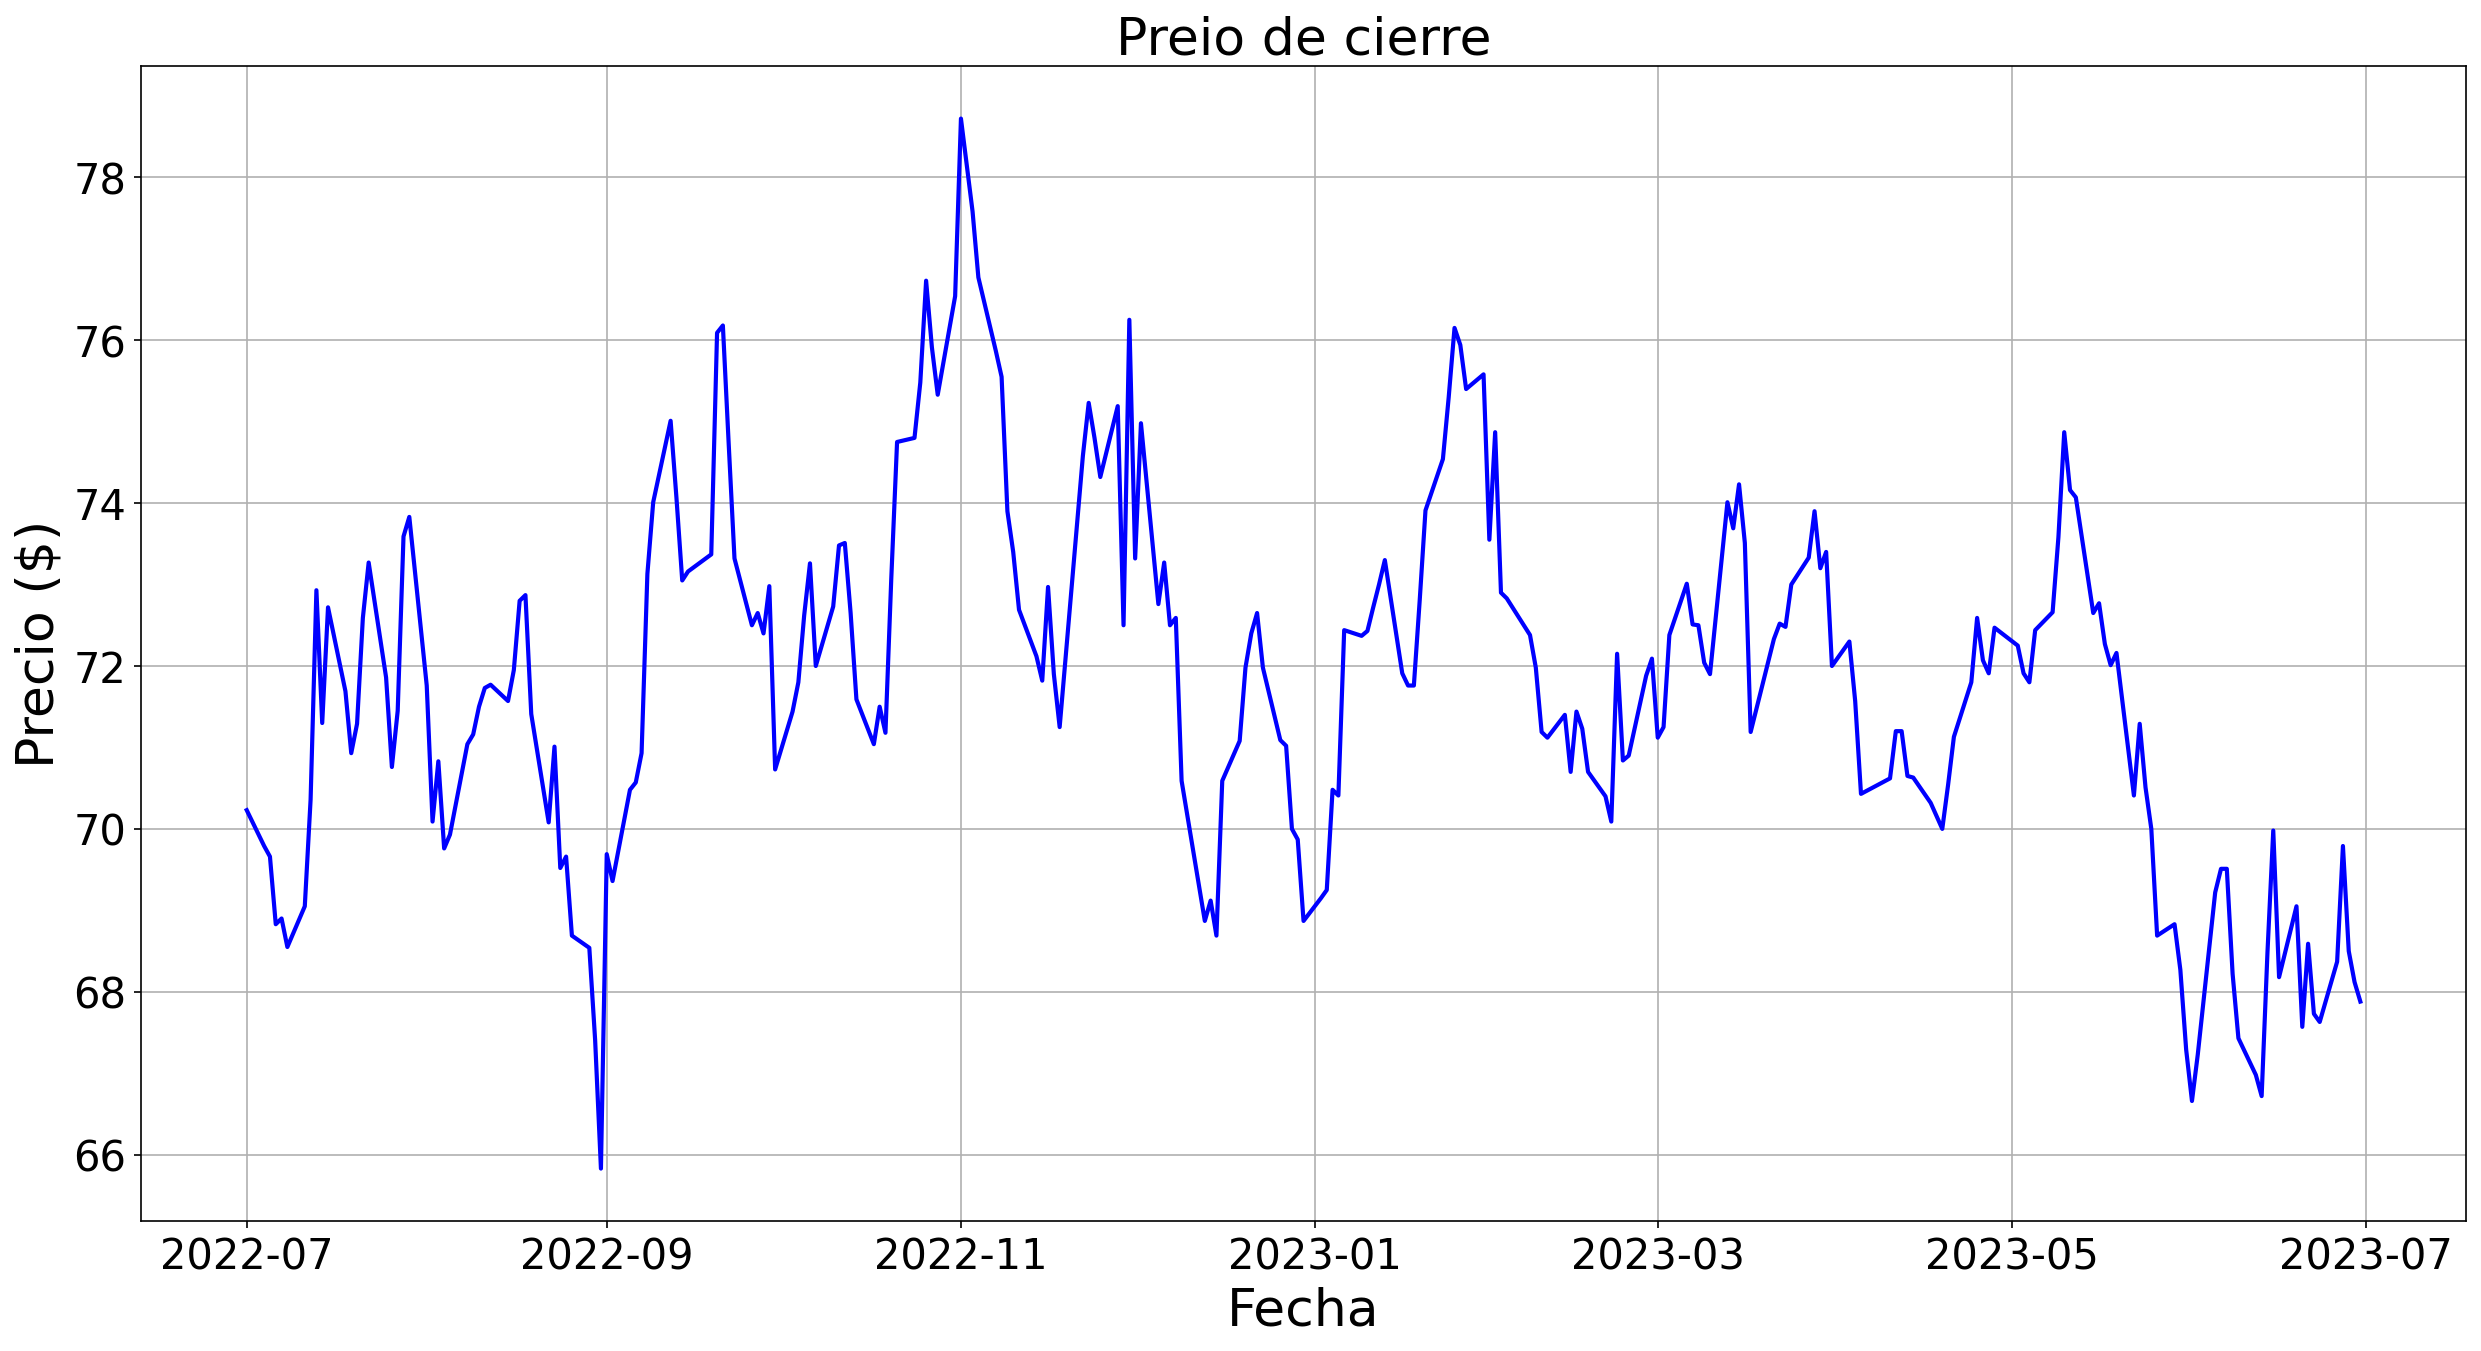

In [35]:
plt.figure(figsize=(20,10), dpi=150)
plt.plot(df.index, df['Close'], lw=2, color='blue')
plt.xlabel('Fecha', fontdict = {'fontsize':25})
plt.ylabel('Precio ($)', fontdict = {'fontsize': 25})
plt.title('Preio de cierre', fontsize = 25)
plt.tick_params(labelsize = 20) #para el tamaño de la leyenda
plt.grid(True)
plt.show()

CONTAMINANTES 2022

In [38]:
#abrimos el archivo
ruta = 'https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/ARCHIVOS/contam2022.csv'
contam = pd.read_csv (ruta, sep=',', parse_dates = True, index_col=0) #parse_dates=true indica que se interpretan las fechas automaticamente como tipo Datatime
contam.head()

,Centro Ozono,Centro diÛxido de azufre,Centro diÛxido de nitrÛgeno,Centro monÛxido de carbono,Centro PM10
Fecha,,,,,
2022-01-01,36.916667,6.333333,22.458333,10.208333,106.916667
2022-01-02,17.250000,7.750000,15.833333,9.500000,97.875000
2022-01-03,24.083333,7.833333,17.875000,5.041667,61.958333
2022-01-04,27.583333,27.416667,27.125000,8.250000,91.333333
2022-01-05,30.875000,12.833333,25.791667,9.791667,94.000000


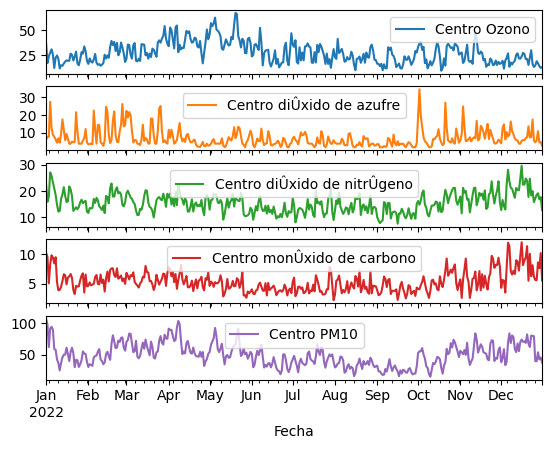

In [39]:
contam.plot(subplots=True)
plt.show()

rama 2016

In [40]:
#abrimos el archivo
ruta = 'https://raw.githubusercontent.com/marinlopabi/Temas_Selectos_PQ_26-I/refs/heads/main/ARCHIVOS/rama_2016.csv'
rama = pd.read_csv (ruta, sep=',', parse_dates = True, index_col=0) #parse_dates=true indica que se interpretan las fechas automaticamente como tipo Datatime
rama.head()

,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
fecha,,,,,,,,
2016-01-01,0.962269,13.831140,29.712719,43.567982,33.471014,115.334071,86.909910,21.117647
2016-01-02,0.610673,7.929515,21.085903,29.006608,24.540835,42.101990,24.508711,5.218673
2016-01-03,0.711463,16.601382,26.645161,43.267281,19.586792,45.245033,28.209677,17.517157
2016-01-04,0.916995,33.433566,31.664336,65.149184,9.396190,57.624709,39.484099,12.179361
2016-01-05,0.991036,49.722222,24.656085,74.378307,17.697917,35.979960,21.185915,2.578249


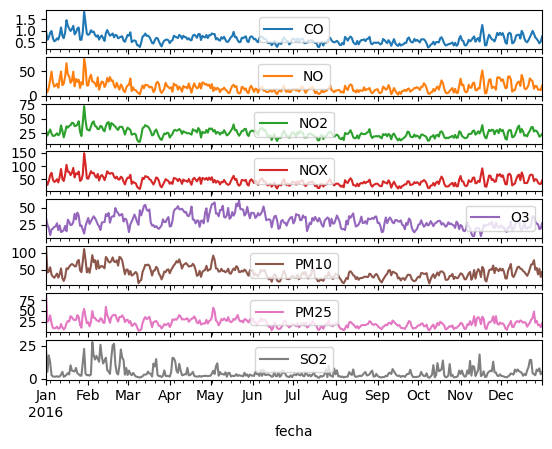

In [41]:
rama.plot(subplots=True)
plt.show()

mejora con IA "Claude"

/tmp/ipykernel_426/2597807583.py:243: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


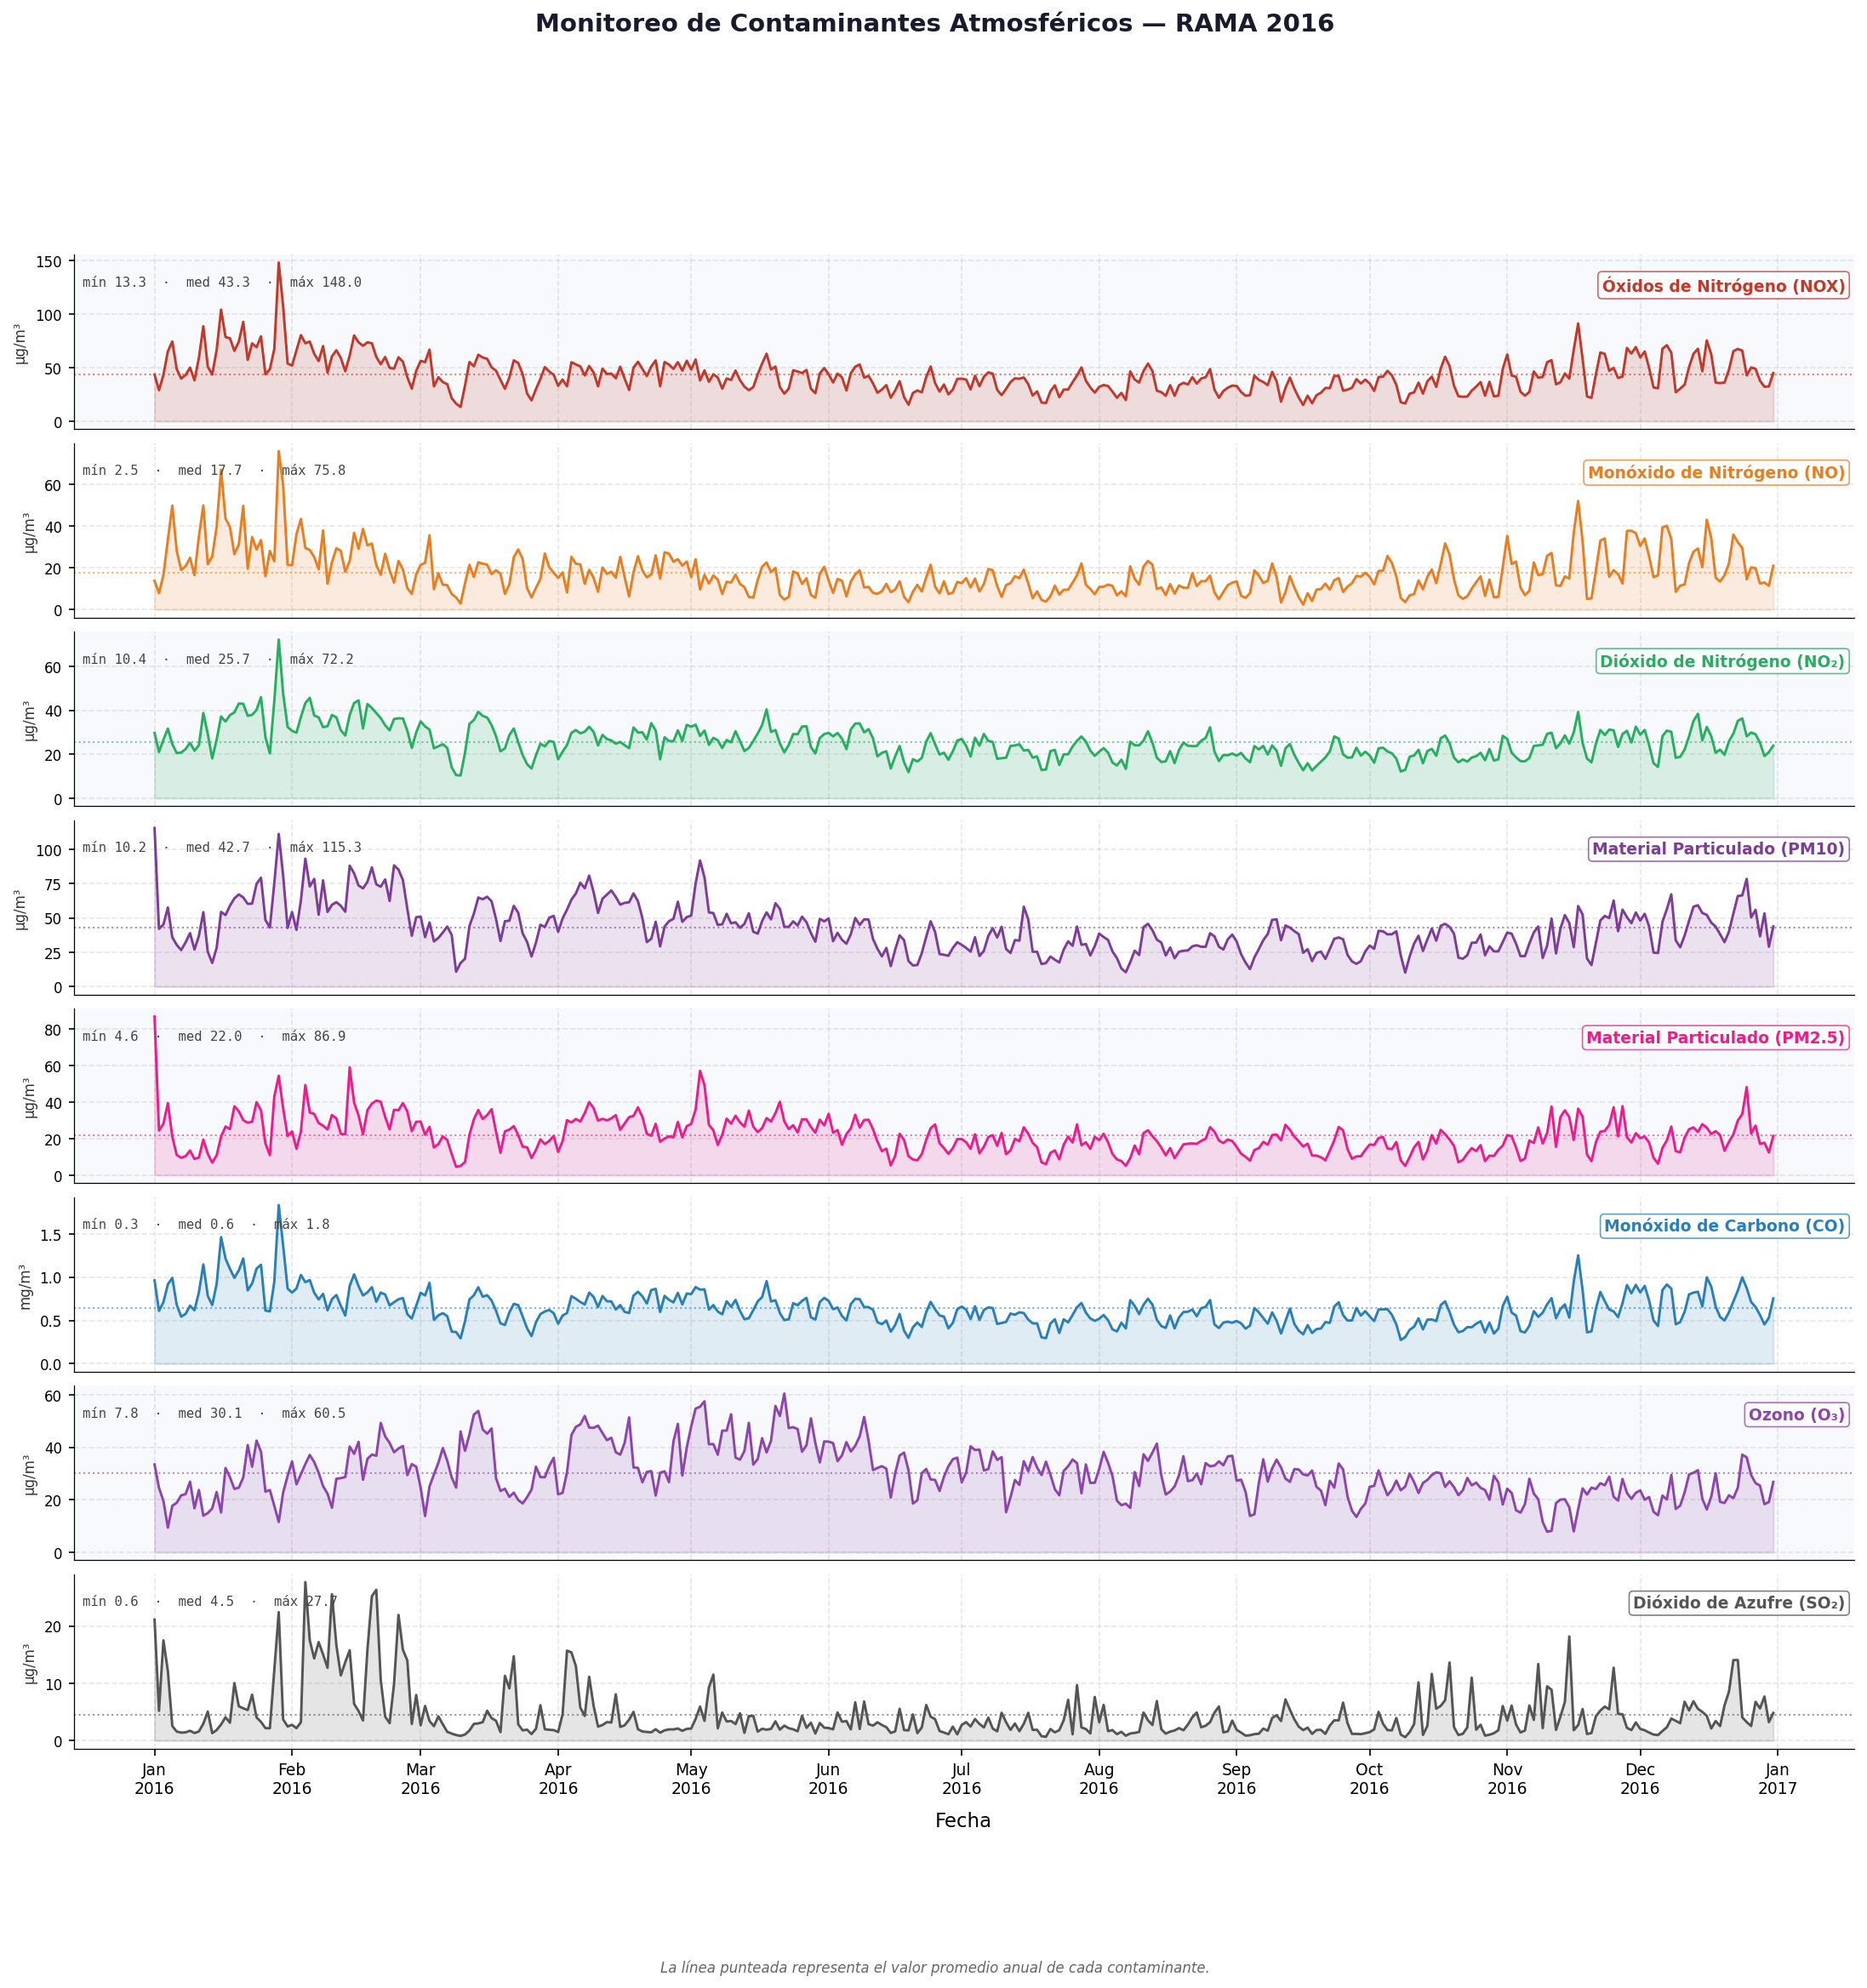

In [42]:
import pandas as pd                    # Manipulación y análisis de datos tabulares
import matplotlib.pyplot as plt        # Librería principal para crear gráficas
import matplotlib.dates as mdates      # Formateo de fechas en los ejes
import matplotlib.gridspec as gridspec # Control avanzado del layout de subgráficas
import numpy as np                     # Operaciones numéricas sobre arrays


# ══════════════════════════════════════════════════════════════════════
# ── 1. CONFIGURACIÓN CENTRALIZADA ────────────────────────────────────
#    Modifica SOLO esta sección para ajustar la gráfica.
# ══════════════════════════════════════════════════════════════════════

# — Contaminantes en el orden visual deseado (de mayor a menor impacto) —
# Cada entrada: "columna_en_df" → (color, "Unidad", "Nombre completo")
CONTAMINANTES = {
    "NOX":  ("#C0392B", "µg/m³", "Óxidos de Nitrógeno (NOX)"),
    "NO":   ("#E67E22", "µg/m³", "Monóxido de Nitrógeno (NO)"),
    "NO2":  ("#27AE60", "µg/m³", "Dióxido de Nitrógeno (NO₂)"),
    "PM10": ("#7D3C98", "µg/m³", "Material Particulado (PM10)"),
    "PM25": ("#E91E8C", "µg/m³", "Material Particulado (PM2.5)"),
    "CO":   ("#2980B9", "mg/m³", "Monóxido de Carbono (CO)"),
    "O3":   ("#8E44AD", "µg/m³", "Ozono (O₃)"),
    "SO2":  ("#555555", "µg/m³", "Dióxido de Azufre (SO₂)"),
}

# — Configuración visual general —
TITULO_PRINCIPAL = "Monitoreo de Contaminantes Atmosféricos — RAMA 2016"
FIGURA_ANCHO     = 18          # Ancho total de la figura en pulgadas
ALTURA_POR_PANEL = 1.9         # Alto de cada panel individual en pulgadas
FIGURA_DPI       = 150         # Resolución de la figura (mayor = más nítida)
ALPHA_RELLENO    = 0.15        # Transparencia del relleno bajo cada curva (0–1)
GROSOR_LINEA     = 1.4         # Grosor de cada línea de contaminante

# — Formato del eje X —
FORMATO_FECHA   = "%b\n%Y"     # Formato de etiquetas: "Ene\n2016"
INTERVALO_MESES = 1            # Una etiqueta por mes

# — Exportación —
GUARDAR_IMAGEN = False
NOMBRE_ARCHIVO = "contaminantes_rama.png"


# ══════════════════════════════════════════════════════════════════════
# ── 2. PREPARACIÓN DE DATOS ───────────────────────────────────────────
#    Asegura que el índice sea DatetimeIndex y filtra solo las columnas
#    de contaminantes definidas en CONTAMINANTES.
# ══════════════════════════════════════════════════════════════════════

# Asegura que el índice del DataFrame sea de tipo fecha para que mdates funcione
if not isinstance(rama.index, pd.DatetimeIndex):
    rama.index = pd.to_datetime(rama.index)   # Convierte el índice a fechas si aún no lo es

# Filtra solo los contaminantes que existen en el DataFrame para evitar KeyErrors
cols_disponibles = [c for c in CONTAMINANTES if c in rama.columns]

# Calcula estadísticas por contaminante (usadas en las etiquetas de cada panel)
stats = {
    col: {
        "min":  rama[col].min(),
        "max":  rama[col].max(),
        "mean": rama[col].mean(),
    }
    for col in cols_disponibles
}


# ══════════════════════════════════════════════════════════════════════
# ── 3. CREACIÓN DE LA FIGURA CON GRIDSPEC ────────────────────────────
#    GridSpec permite controlar el espaciado entre paneles con precisión,
#    a diferencia de subplots() que usa espaciado uniforme fijo.
# ══════════════════════════════════════════════════════════════════════

n = len(cols_disponibles)                          # Número de paneles = número de contaminantes disponibles
altura_total = ALTURA_POR_PANEL * n                # Altura total proporcional al número de paneles

fig = plt.figure(figsize=(FIGURA_ANCHO, altura_total), dpi=FIGURA_DPI)

# GridSpec crea una cuadrícula de n filas × 1 columna con espaciado vertical controlado
gs = gridspec.GridSpec(
    n, 1,
    hspace=0.08,          # Espaciado vertical entre paneles (valores pequeños = más compacto)
    figure=fig
)

# Crea la lista de ejes (uno por contaminante); sharex vincula el eje X de todos los paneles
axes = []
for i in range(n):
    if i == 0:
        ax = fig.add_subplot(gs[i])          # Primer panel: se crea independiente
    else:
        ax = fig.add_subplot(gs[i], sharex=axes[0])   # Los demás comparten el eje X del primero
    axes.append(ax)


# ══════════════════════════════════════════════════════════════════════
# ── 4. TRAZADO DE CADA PANEL ─────────────────────────────────════════
# ══════════════════════════════════════════════════════════════════════

for i, col in enumerate(cols_disponibles):
    ax                       = axes[i]
    color, unidad, nombre    = CONTAMINANTES[col]   # Extrae parámetros del diccionario de configuración
    serie                    = rama[col].dropna()   # Elimina NaN para evitar huecos o errores

    # — Línea principal del contaminante —
    ax.plot(
        serie.index,          # Eje X: fechas
        serie.values,         # Eje Y: concentración del contaminante
        color=color,          # Color único por contaminante
        lw=GROSOR_LINEA,      # Grosor de línea configurable
        zorder=3              # Capa 3: encima del relleno y la cuadrícula
    )

    # — Relleno bajo la curva para enfatizar visualmente el área —
    ax.fill_between(
        serie.index,
        serie.values,
        alpha=ALPHA_RELLENO,  # Transparencia suave para no distraer de la línea
        color=color,
        zorder=2
    )

    # — Línea horizontal del promedio como referencia —
    ax.axhline(
        stats[col]["mean"],
        color=color,
        linestyle=":",        # Punteada muy suave para no saturar el panel
        lw=1.0,
        alpha=0.6,
        zorder=1
    )

    # — Etiqueta del nombre del contaminante dentro del panel (esquina superior derecha) —
    ax.text(
        0.995, 0.88,                   # Posición relativa al panel
        nombre,
        transform=ax.transAxes,        # Coordenadas relativas (0=izquierda/abajo, 1=derecha/arriba)
        fontsize=9,
        fontweight="bold",
        color=color,
        ha="right",                    # Alineado a la derecha
        va="top",
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor=color,
            alpha=0.75,
            linewidth=0.8
        )
    )

    # — Mini cuadro de estadísticas (mín / media / máx) en esquina superior izquierda —
    texto_stat = f"mín {stats[col]['min']:.1f}  ·  med {stats[col]['mean']:.1f}  ·  máx {stats[col]['max']:.1f}"
    ax.text(
        0.005, 0.88,
        texto_stat,
        transform=ax.transAxes,
        fontsize=7.5,
        color="#444444",
        va="top",
        fontfamily="monospace"         # Monoespaciado para alinear números
    )

    # — Etiqueta del eje Y: unidad de medición —
    ax.set_ylabel(unidad, fontsize=8, labelpad=4, color="#333333")

    # — Cuadrícula sutil y estilo de bordes —
    ax.grid(True, linestyle="--", alpha=0.3, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)       # Oculta bordes redundantes
    ax.spines[["left", "bottom"]].set_linewidth(0.6)

    # — Tamaño de las marcas del eje Y —
    ax.tick_params(axis="y", labelsize=8, length=3)

    # — Oculta las etiquetas del eje X en todos los paneles excepto el último —
    # Esto evita repetición y hace la gráfica más compacta y limpia
    if i < n - 1:
        plt.setp(ax.get_xticklabels(), visible=False)    # Oculta etiquetas de fecha
        ax.tick_params(axis="x", length=0)               # Oculta también las marcas del eje X

    # — Fondo alternado entre paneles pares e impares para facilitar la lectura —
    if i % 2 == 0:
        ax.set_facecolor("#F7F9FC")   # Azul muy pálido en paneles pares
    else:
        ax.set_facecolor("#FFFFFF")   # Blanco en paneles impares


# ══════════════════════════════════════════════════════════════════════
# ── 5. FORMATO DEL EJE X (solo en el panel inferior) ─────────────────
# ══════════════════════════════════════════════════════════════════════

# El eje X compartido se configura una sola vez en el último panel
ax_bottom = axes[-1]

# Coloca una marca por mes
ax_bottom.xaxis.set_major_locator(mdates.MonthLocator(interval=INTERVALO_MESES))

# Formatea las etiquetas con el patrón definido en FORMATO_FECHA
ax_bottom.xaxis.set_major_formatter(mdates.DateFormatter(FORMATO_FECHA))

# Aplica tamaño y alineación a las etiquetas de fecha
ax_bottom.tick_params(axis="x", labelsize=9, length=4)
plt.setp(ax_bottom.get_xticklabels(), ha="center")

# Etiqueta del eje X en el panel inferior
ax_bottom.set_xlabel("Fecha", fontsize=11, labelpad=8)


# ══════════════════════════════════════════════════════════════════════
# ── 6. TÍTULO PRINCIPAL ───────────────────────────────────────────────
#    Se coloca en la figura completa (no en un panel individual) para
#    que quede centrado sobre todos los paneles.
# ══════════════════════════════════════════════════════════════════════

fig.suptitle(
    TITULO_PRINCIPAL,
    fontsize=14,
    fontweight="bold",
    y=1.005,              # Ligeramente por encima del área de paneles
    color="#1A1A2E"
)


# ══════════════════════════════════════════════════════════════════════
# ── 7. NOTA AL PIE CON REFERENCIA DE LA LÍNEA PUNTEADA ───────────────
# ══════════════════════════════════════════════════════════════════════

# Añade una nota en la parte inferior de la figura para explicar la línea punteada
fig.text(
    0.5, -0.005,                   # Centrado horizontalmente, justo debajo del último panel
    "La línea punteada representa el valor promedio anual de cada contaminante.",
    ha="center",
    fontsize=8,
    color="#666666",
    style="italic"
)


# ══════════════════════════════════════════════════════════════════════
# ── 8. AJUSTE FINAL Y SALIDA ──────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════

# tight_layout ajusta márgenes para que nada quede recortado
plt.tight_layout()

if GUARDAR_IMAGEN:
    plt.savefig(NOMBRE_ARCHIVO, bbox_inches="tight", dpi=FIGURA_DPI)
    print(f"Gráfica guardada como '{NOMBRE_ARCHIVO}'")

plt.show()

Caracteristicas de una serie temporal

Conjunto de observaciones ordenadas en el tiempo. para analizar es fundamental identificar sus patrones y propiedades internas

Tendencia es el movimiento general de la serie a largo plazo. Puede ser:

* CRECIENTE
* DECRECIENTE
